In [7]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, applications
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

try:
    from google.colab import drive
    _HAS_COLAB = True
except ImportError:
    drive = None
    _HAS_COLAB = False

if _HAS_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass

# Reemplaza la configuración de la ruta por esto:
BASE_DIR = r'C:\Users\bner\Documents\ues\ML\Proyecto\maize_dataset\clean'

# Agregamos la ruta de guardado del modelo
CARPETA_DESTINO = 'modelos_locales'
os.makedirs(CARPETA_DESTINO, exist_ok=True)
ruta_small = os.path.join(CARPETA_DESTINO, 'mobilenetv3_small_mejor.keras')

if os.path.exists(BASE_DIR):
    class_names = [d for d in sorted(os.listdir(BASE_DIR)) if os.path.isdir(os.path.join(BASE_DIR, d))]
    print(f" Ruta encontrada: {BASE_DIR}")
    print(f" Clases detectadas listas para entrenar: {class_names}")
else:
    print(f" Error: No se encontró la ruta {BASE_DIR}.")

 Ruta encontrada: C:\Users\bner\Documents\ues\ML\Proyecto\maize_dataset\clean
 Clases detectadas listas para entrenar: ['aphids_pest', 'common_rust', 'fall_armyworm', 'gray_leaf_spot', 'healthy', 'nitrogen_deficiency', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'potassium_deficiency']


In [8]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ ¡Excelente! GPU detectada: {gpus}")
else:
    print("⚠️ ADVERTENCIA: No se detectó GPU.")

⚠️ ADVERTENCIA: No se detectó GPU.


In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Cargando y dividiendo el dataset automáticamente...")

train_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)
test_dataset = val_test_dataset.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
# Corregido a 300 para proteger la RAM
train_dataset = train_dataset_raw.shuffle(300).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\n Conjuntos de datos listos.")

Cargando y dividiendo el dataset automáticamente...
Found 25284 files belonging to 9 classes.
Using 20228 files for training.
Found 25284 files belonging to 9 classes.
Using 5056 files for validation.

 Conjuntos de datos listos.


In [10]:
print(f"Clases a balancear: {class_names}")
print("Calculando desbalance de forma optimizada en memoria...")

y_train_indices = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_dataset_raw], axis=0)

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights_dict = dict(enumerate(pesos))

print("\nPesos de compensación generados:")
for idx, clase in enumerate(class_names):
    print(f" - {clase}: {class_weights_dict[idx]:.4f}")

Clases a balancear: ['aphids_pest', 'common_rust', 'fall_armyworm', 'gray_leaf_spot', 'healthy', 'nitrogen_deficiency', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'potassium_deficiency']
Calculando desbalance de forma optimizada en memoria...

Pesos de compensación generados:
 - aphids_pest: 38.7510
 - common_rust: 1.2175
 - fall_armyworm: 0.5799
 - gray_leaf_spot: 2.5140
 - healthy: 0.3199
 - nitrogen_deficiency: 5.5771
 - northern_corn_leaf_blight: 0.4146
 - phosphorus_deficiency: 4.5497
 - potassium_deficiency: 10.6519


In [11]:
# 1. Data Augmentation Mejorado (Con Brillo)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
  layers.RandomBrightness(0.2), 
], name="data_augmentation_layer")

# 2. Cargar modelo base
base_model = applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)

# 3. FINE-TUNING (Descongelamos las últimas 20 capas)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 4. Ensamblamos la red
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x) # Subimos a 0.4 para evitar memorización

num_clases = len(class_names)
outputs = layers.Dense(num_clases, activation='softmax', name='prediccion_enfermedad')(x)

model = tf.keras.Model(inputs, outputs)

# 5. Compilación con tasa ajustada al Fine-Tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

print(f" Arquitectura construida para {num_clases} clases. Resumen del modelo:")
model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 Arquitectura construida para 9 clases. Resumen del modelo:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion_enfermedad (Dense)   │ (None, 9)              │         5,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,313 (3.60 MB)

 Trainable params: 355,929 (1.36 MB)

 Non-trainable params: 588,384 (2.24 MB)

In [12]:
import os
import tensorflow as tf

# Subimos un poco las épocas porque el EarlyStopping nos protegerá si termina antes
EPOCHS = 25 

# 1. Callback para guardar localmente el MEJOR modelo
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    ruta_small,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

# 2. Callback para detener si empieza a sobreajustarse
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=6,
    restore_best_weights=True,
    monitor='val_loss'
)

# 3. Callback para aplanar la curva bajando el Learning Rate
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print(f"\n🚀 ¡Iniciando el entrenamiento optimizado en la GPU!")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

print(f"\n Entrenamiento finalizado. El mejor modelo se guardó en: {ruta_small}")


🚀 ¡Iniciando el entrenamiento optimizado en la GPU!
Epoch 1/25


633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5436 - loss: 1.2946 - precision: 0.7504 - recall: 0.3544
Epoch 1: val_loss improved from None to 0.53276, saving model to modelos_locales\mobilenetv3_small_mejor.keras

Epoch 1: finished saving model to modelos_locales\mobilenetv3_small_mejor.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 112s 155ms/step - accuracy: 0.6905 - loss: 0.8852 - precision: 0.8362 - recall: 0.5557 - val_accuracy: 0.8287 - val_loss: 0.5328 - val_precision: 0.8653 - val_recall: 0.7852 - learning_rate: 5.0000e-04
Epoch 2/25
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8335 - loss: 0.5009 - precision: 0.8812 - recall: 0.7908
Epoch 2: val_loss improved from 0.53276 to 0.42000, saving model to modelos_locales\mobilenetv3_small_mejor.keras

Epoch 2: finished saving model to modelos_locales\mobilenetv3_small_mejor.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 97s 142ms/step - accuracy: 0.8439 - loss: 0.4724 - precision: 0.8882 - recall: 0.8061 - val_accuracy: 0.8608 - val

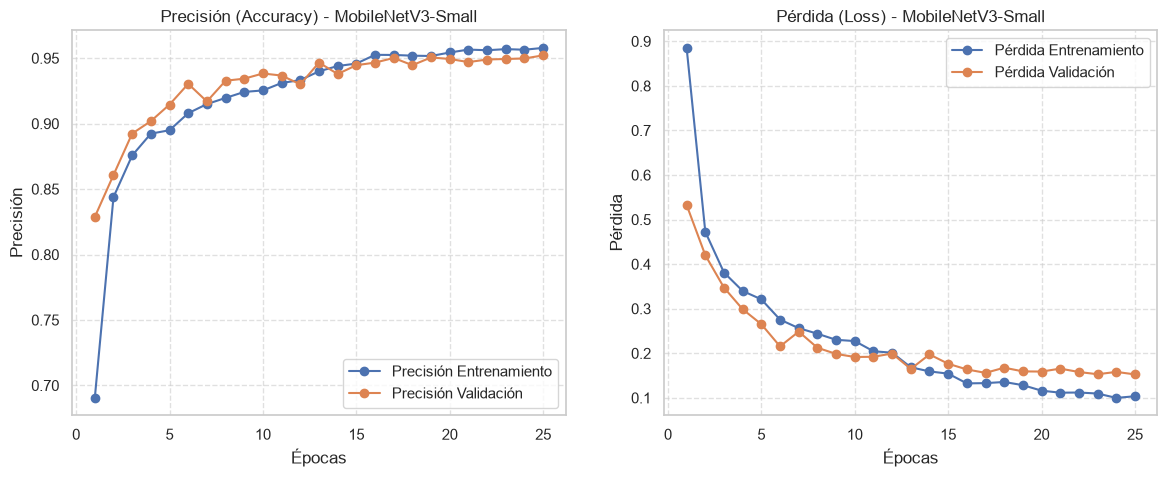

In [13]:
import matplotlib.pyplot as plt

# Extraer datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Precisión Validación', marker='o')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy) - MobileNetV3-Small')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento', marker='o')
plt.plot(epochs_range, val_loss, label='Pérdida Validación', marker='o')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss) - MobileNetV3-Small')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Cargando el MEJOR modelo guardado para la evaluación final...
Evaluando el modelo con el conjunto de prueba (Test Dataset)...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9458 - loss: 0.1637 - precision: 0.9502 - recall: 0.9442

Resultados Finales en Test -> Precisión: 94.58% | Pérdida: 0.1637
Generando predicciones detalladas...

REPORTE DE CLASIFICACIÓN FINAL
                           precision    recall  f1-score   support

              aphids_pest       0.91      1.00      0.95        10
              common_rust       0.99      1.00      1.00       215
            fall_armyworm       0.96      0.93      0.95       483
           gray_leaf_spot       0.83      0.97      0.89       118
                  healthy       0.96      0.98      0.97       859
      nitrogen_deficiency       0.86      0.78      0.82        55
northern_corn_leaf_blight       0.97      0.92      0.95       705
    phosphorus_deficiency       0.84      0.88      0.86        58
     potassium_defici

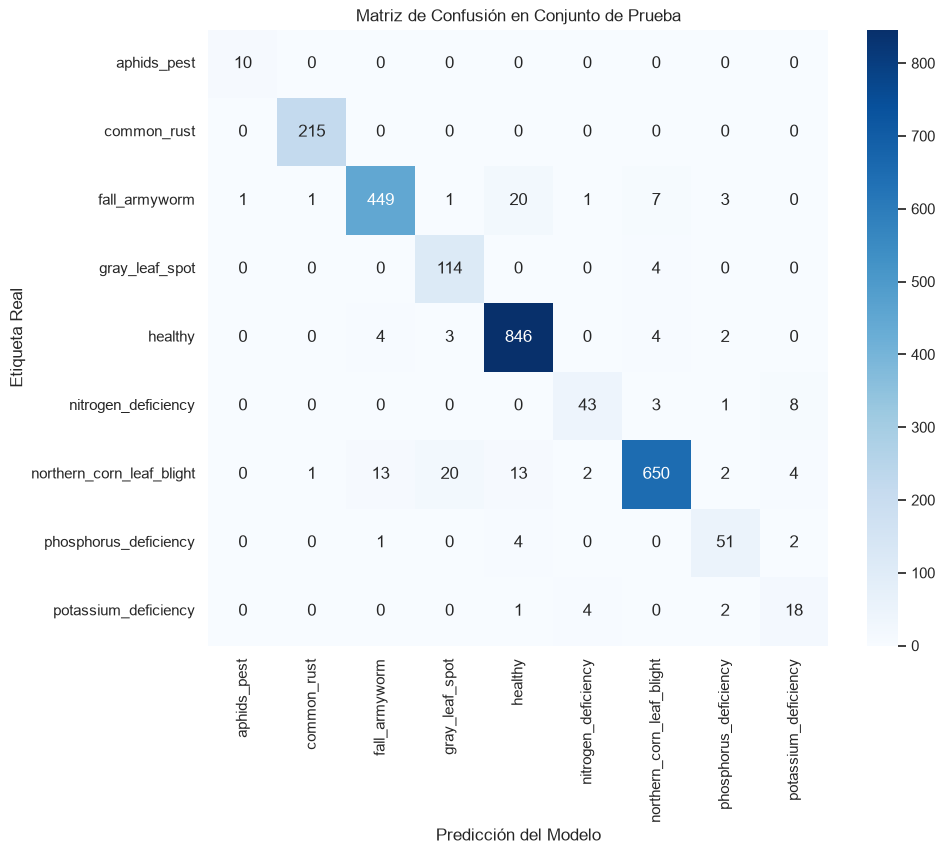

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print("Cargando el MEJOR modelo guardado para la evaluación final...")
mejor_modelo = tf.keras.models.load_model(ruta_small)

print("Evaluando el modelo con el conjunto de prueba (Test Dataset)...")
test_loss, test_acc, test_prec, test_rec = mejor_modelo.evaluate(test_dataset)
print(f"\nResultados Finales en Test -> Precisión: {test_acc*100:.2f}% | Pérdida: {test_loss:.4f}")

y_true = []
y_pred = []

print("Generando predicciones detalladas...")
for images, labels in test_dataset:
    preds = mejor_modelo.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión en Conjunto de Prueba')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

In [15]:
import tensorflow as tf
import os

print("Iniciando compresión y conversión a TensorFlow Lite...")

# 1. Cargamos el mejor modelo guardado
modelo_final = tf.keras.models.load_model(ruta_small)

# 2. Configuramos el convertidor con cuantización por defecto
converter = tf.lite.TFLiteConverter.from_keras_model(modelo_final)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 3. Guardamos el archivo .tflite en tu carpeta local
tflite_path = os.path.join(CARPETA_DESTINO, 'mobilenetv3_small_mejor.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# 4. Guardamos las etiquetas para que Vue sepa leer las predicciones
labels_path = os.path.join(CARPETA_DESTINO, 'etiquetas_maiz.txt')
with open(labels_path, 'w') as f:
    f.write('\n'.join(class_names))

print(f"\n✅ ¡Éxito! Modelo comprimido listo para la web guardado en: {tflite_path}")
print(f"✅ Diccionario de etiquetas guardado en: {labels_path}")

Iniciando compresión y conversión a TensorFlow Lite...
INFO:tensorflow:Assets written to: C:\Users\bner\AppData\Local\Temp\tmpmmlqweph\assets


INFO:tensorflow:Assets written to: C:\Users\bner\AppData\Local\Temp\tmpmmlqweph\assets


Saved artifact at 'C:\Users\bner\AppData\Local\Temp\tmpmmlqweph'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  1982014468368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982020553616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982020550736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982014459920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982020558032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982020559760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982021773328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982021776784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982021776400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1982021770640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19820